# Practica: NLP - Descarga y EDA

Alumno: Hannibal Tomasson Izquierdo

Instrucciones: El alumno descargará el/los corpus que desee y realizará un análisis exploratorio de los datos.
Este ejercicio deberá contener:
- Cardinalidad del vocabulario
- Distribución de reviews por número de estrellas
- Nº de reviews positivas y negativas
- N-grams más frecuentes
- Nubes de palabras
- Visualización en 2 dimensiones de algunos word embeddings calculados con
Word2Vec (elegir 4-5 palabras y pintar las top 10 más similares)
- Conclusiones de la exploración
- Cualquier otra métrica / exploración / cálculo que el alumno considere




Hemos decidido descargarnos una parte del gran dataset de reviews que Julian McAuley, profesor de la UC San Diego, tiene preparado. El tamano total de este dataset es muy grande, y como no necesitamos tantos datos para completar los objetivos de esta practica, vamos a extraer solo una parte.

Para asegurarnos de que los datos con los que vamos a trabajar nos proporcionan una muestra equilibrada de las reviews, vamos a leer una cantidad mayor de entradas, y seleccionar aleatoriamente de entre estas reviews positivas y negativas.

In [5]:
import requests

url = "http://snap.stanford.edu/data/amazon/productGraph/categoryFiles/reviews_Books_5.json.gz"
file_path = "reviews_Books_5.json.gz"

response = requests.get(url)
with open(file_path, "wb") as f:
    for chunk in response.iter_content(chunk_size=1024):
        if chunk:
            f.write(chunk)

print("Dataset descargado correctamente.")

Dataset descargado correctamente.


In [6]:
import gzip
import json
import pandas as pd

file_path = "reviews_Books_5.json.gz"
sample_limit = 50000

data = []
with gzip.open(file_path, 'rt', encoding='utf-8') as f:
    for i, line in enumerate(f):
        if i >= sample_limit:
            break
        data.append(json.loads(line))

df_full = pd.DataFrame(data)

# Comprobamos la distribucion de las reviews
print(df_full['overall'].value_counts().sort_index())


# Definimos reviews positivas (4-5) y negativas (1-2)
df_filtered = df_full[df_full['overall'].isin([1, 2, 4, 5])].copy()
df_filtered['sentiment'] = df_filtered['overall'].apply(lambda x: 'pos' if x >= 4 else 'neg')

# Clasificamos las reviews y creamos el dataset equilibrado
df_sampled = (
    df_filtered.groupby('sentiment', group_keys=False).apply(lambda x: x.sample(n=2500, random_state=42)).reset_index(drop=True)
)


overall
1.0     2328
2.0     2853
3.0     5448
4.0    11163
5.0    28208
Name: count, dtype: int64


<ipython-input-6-bd36ae32e662>:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_filtered.groupby('sentiment', group_keys=False).apply(lambda x: x.sample(n=2500, random_state=42)).reset_index(drop=True)


In [7]:
# Mostramos las primeras filas y un total de reviews
print(df_sampled['sentiment'].value_counts())
print(df_sampled['overall'].value_counts().sort_index())
df_sampled.head()

sentiment
neg    2500
pos    2500
Name: count, dtype: int64
overall
1.0    1115
2.0    1385
4.0     749
5.0    1751
Name: count, dtype: int64


,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime,sentiment
0,A24O15MYDNLZBE,000755947X,"Smart4 ""Smart4 LLC""","[0, 6]",At the beginning of each chapter it switches b...,1.0,Kinda Trashy,1398988800,"05 2, 2014",neg
1,A3SYT3AMEMB4RH,000721278X,wingthing,"[9, 11]","Historically inaccurate, a painfully rushed th...",1.0,A big disappointment,1163030400,"11 9, 2006",neg
2,A333CAV0NHSMRO,0002247399,"A. Purcell ""CottonBlossom""","[6, 7]",I've spent 5 months reading these books. Each ...,1.0,Not pleased.,1385510400,"11 27, 2013",neg
3,A14DTUVG1WDW3E,0007493754,Cal,"[8, 9]",Can honestly say this is the first book of Goo...,1.0,Padded out to occuply space,1379808000,"09 22, 2013",neg
4,A1BJUMKKRLK9XX,0007124015,Jagadeesh K. Venugopal,"[197, 216]",Note -- Tolkien's work is rated 5 stars. The p...,2.0,Poor quality control,1102118400,"12 4, 2004",neg


Como podemos comprobar, hemos podido dividir correctamente nuestra muestra para obtener 2500 reviews positivas y 2500 negativas. Sin embargo, el numero de reviews de cada puntuacion (1, 2, 3, 4) no es exactamente el mismo. Podriamos repetir la clasificacion aumentando la muestra original para intentar solucionarlo, pero creemos que dado el objetivo de esta practica, esta muestra sera adecuada.

Para no tener que realizar esta division cada vez que reiniciemos este notebook, asi como para poder acceder facilmente al dataset desde otros notebooks, vamos a guardar este muestreo en nuestro Google Drive.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Especificamos ruta de guardado
output_path = "/content/drive/MyDrive/Colab Notebooks/NLP/Practica/reviews_amazon_books_balanced.csv"

# Guardamos como CSV
df_sampled.to_csv(output_path, index=False)

print("Archivo guardado en Google Drive.")

NameError: name 'df_sampled' is not defined

Ahora que ya tenemos nuestro dataset, vamos a proceder a explorarlo. Primero, vamos a comprobar la cardinalidad del vocabulario, y a visualizar la distribucion de las puntuaciones de las reviews.

In [6]:
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd
import nltk
import re
import os

nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [7]:
# Cargamos el dataset en caso de que hayamos reiniciado el notebook

cvs_path = "/content/drive/MyDrive/Colab Notebooks/NLP/Practica/reviews_amazon_books_balanced.csv"
df_sampled = pd.read_csv(cvs_path)

if 'df_sampled' not in locals():
    if os.path.exists(csv_path):
        print("Cargando dataset desde Google Drive...")
        df_sampled = pd.read_csv(csv_path)
    else:
        raise FileNotFoundError("El archivo CSV no se encuentra en la ruta especificada.")

In [8]:
# Creamos una funcion tokenizadora

def simple_tokenizer(text):
    tokens = nltk.word_tokenize(re.sub(r"[^\w\s]", "", str(text).lower()))
    return tokens

# Aplicamos la funcion al texto de las reviews

all_tokens = df_sampled['reviewText'].dropna().apply(simple_tokenizer)

# Aplanamos la lista de listas y contamos las palabras

flat_tokens = [word for tokens in all_tokens for word in tokens]
vocab_counter = Counter(flat_tokens)

print("Cardinalidad del Vocabulario:", len(vocab_counter))

Cardinalidad del Vocabulario: 38877


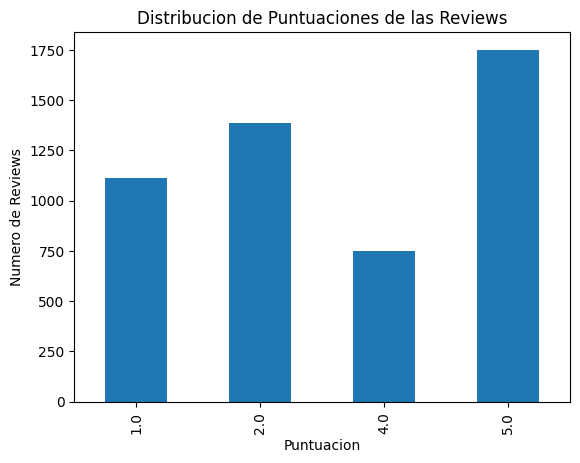

In [9]:
# Visualizamos la distribucion de las puntuaciones

df_sampled['overall'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Puntuacion')
plt.ylabel('Numero de Reviews')
plt.title('Distribucion de Puntuaciones de las Reviews')
plt.show()

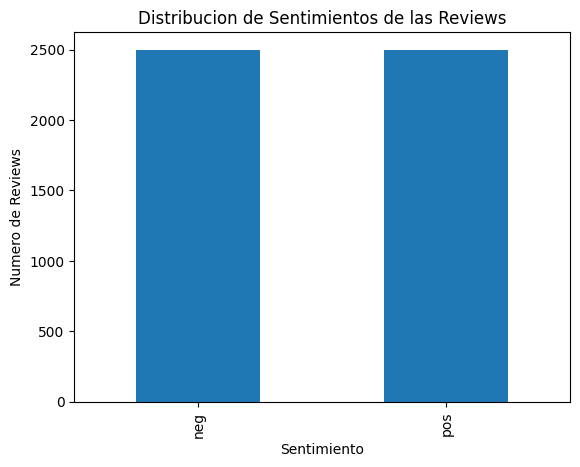

In [10]:
# Visualizamos la distribucion de sentimientos

df_sampled['sentiment'].value_counts().plot(kind='bar')
plt.xlabel('Sentimiento')
plt.ylabel('Numero de Reviews')
plt.title('Distribucion de Sentimientos de las Reviews')
plt.show()

Como ya habiamos avanzado y ahora podemos ver, tenemos una distribucion equilibrada con respecto al sentimiento negativo y positivo. Hay un ligero desequilibrio en el numero de reviews con cada una de las 4 puntuaciones diferentes, pero como ya hemos mencionado, no creemos que suponga un gran problema.


Ahora vamos a ver los n-grams principales de nuestras reviews.

In [11]:
from sklearn.feature_extraction.text import CountVectorizer

In [12]:
# Usamos el texto limpio

texts = df_sampled['reviewText'].dropna().astype(str)

# Definimos funcion para mostrar los n-grams mas frecuentes

def show_top_ngrams(corpus, ngram_range=(1, 1), top_n=20):
    vectorizer = CountVectorizer(ngram_range=ngram_range, stop_words='english')
    X = vectorizer.fit_transform(corpus)
    sum_words = X.sum(axis=0)

    words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)[:top_n]

    print(f"Top {top_n} n-grams (rango={ngram_range}):")
    for word, freq in words_freq:
        print(f"{word:<30} {freq}")


In [13]:
# Ejecutamos la funcion para los unigramas
show_top_ngrams(texts, ngram_range=(1, 1))

Top 20 n-grams (rango=(1, 1)):
book                           9627
read                           3915
story                          3084
just                           2658
like                           2605
characters                     2311
books                          2186
series                         1859
time                           1798
really                         1739
good                           1725
reading                        1591
author                         1408
way                            1311
life                           1260
don                            1241
did                            1213
novel                          1189
great                          1177
people                         1164


In [14]:
# Bigramas
show_top_ngrams(texts, ngram_range=(2, 2))

Top 20 n-grams (rango=(2, 2)):
read book                      449
reading book                   226
ve read                        224
main character                 199
book read                      188
book just                      180
felt like                      176
veronica roth                  161
don know                       161
book series                    158
read books                     152
feel like                      139
tris tobias                    138
recommend book                 134
year old                       133
great book                     124
end book                       119
don think                      116
main characters                116
dance dragons                  116


In [15]:
# Trigramas
show_top_ngrams(texts, ngram_range=(3, 3))

Top 20 n-grams (rango=(3, 3)):
world war ii                   47
old man sea                    34
books ve read                  34
really enjoyed book            31
highly recommend book          30
looking forward reading        22
don waste time                 21
book ve read                   21
girl pearl earring             21
read long time                 21
wanted like book               20
king henry viii                18
doesn make sense               17
16 year old                    16
george rr martin               16
loved books series             16
does good job                  16
looking forward book           15
song ice series                14
didn like book                 14


Los n-grams nos muestran algunos datos interesantes, como que hay un gran numero de reviews comentando libros sobre la Segunda Guerra Mundial, o que algunos autores son mencionados a menudo, como George RR Martin y Veronica Roth.

A continuacion, vamos a generar una nube de palabras con los tokens que mas se repiten.

In [16]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

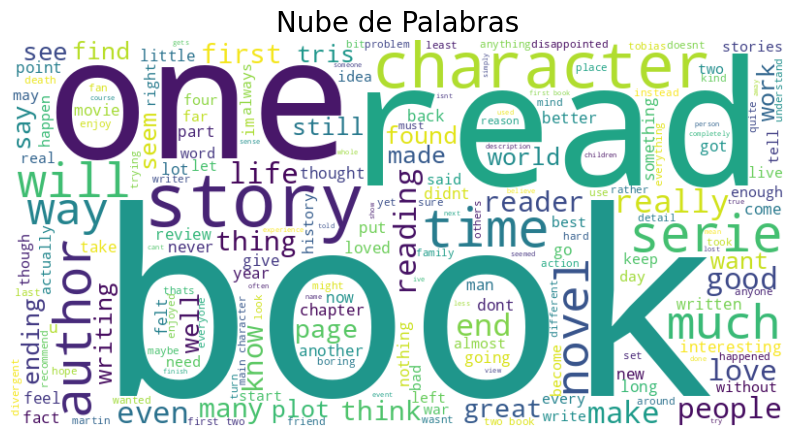

In [17]:
# Unimos todos los tokens en un corpus
text_corpus = " ".join(flat_tokens)

# Creamos la nube de palabras
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_corpus)

# Mostramos la nube
plt.figure(figsize=(10, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Nube de Palabras", fontsize=20)
plt.show()


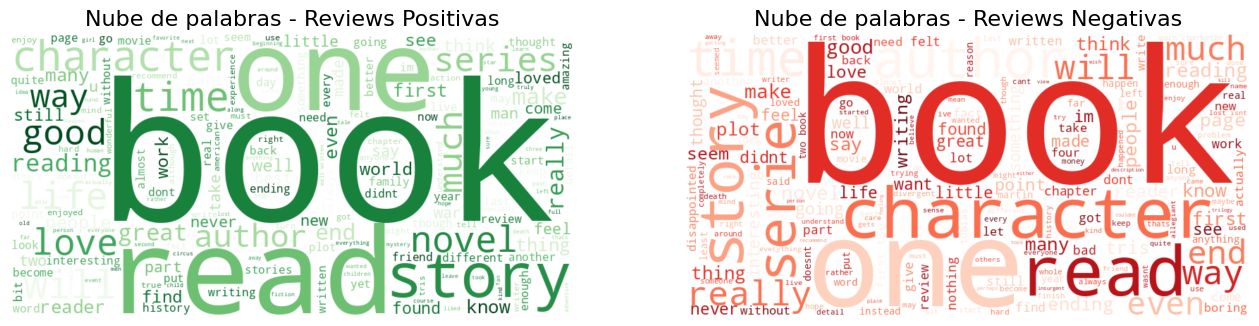

In [18]:
# Generamos listas de tokens por sentimiento
tokens_pos = df_sampled[df_sampled['sentiment'] == 'pos']['reviewText'].dropna().apply(simple_tokenizer)
tokens_neg = df_sampled[df_sampled['sentiment'] == 'neg']['reviewText'].dropna().apply(simple_tokenizer)

# Aplanamos las listas
flat_pos = [word for tokens in tokens_pos for word in tokens]
flat_neg = [word for tokens in tokens_neg for word in tokens]

# Convertimos a texto para WordCloud
text_pos = " ".join(flat_pos)
text_neg = " ".join(flat_neg)

# Creamos las nubes
wordcloud_pos = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(text_pos)
wordcloud_neg = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(text_neg)

# Mostramos las nubes
plt.figure(figsize=(16, 8))

plt.subplot(1, 2, 1)
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis('off')
plt.title("Nube de palabras - Reviews Positivas", fontsize=16)

plt.subplot(1, 2, 2)
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title("Nube de palabras - Reviews Negativas", fontsize=16)

plt.show()


Como vemos, parece que hay muchas palabras en comun entre las dos nubes, como book, one, character, o time. Esto no es demasiado sorprendente por que son todo terminos bastante neutros semanticamente, y se pueden usar tanto para reviews negativas como positivas.

Ahora vamos a generar una visualizacion en 2 dimensiones de algunos word embeddings calculados con Word2Vec. Las palabras que hemos elegido son algunas de las mas comunes en nuestras nubes de palabras.

In [29]:
!pip install --upgrade numpy gensim --force-reinstall

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 1.5 MB/s eta 0:00:00
  Using cached gensim-4.3.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (8.1 kB)
  Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached scipy-1.13.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (60 kB)
Using cached gensim-4.3.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (26.7 MB)
Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.3 MB)
Using cached scipy-1.13.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (38.6 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.2/83.2 kB 5.8 MB/s eta 0:00:00
  Attempting uninstall: wrapt
    Found existing installation: wrapt 1.17.2
    Uninstalling wrapt-1.17.2:
      Successfully uninstalled wrapt-1.17.2
  Attempting un

In [23]:
import gensim
from gensim.models import Word2Vec
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

In [25]:
# Preparamos las reviews tokenizadas
tokenized_reviews = df_sampled['reviewText'].dropna().apply(simple_tokenizer).tolist()

# Entrenamos el model Word2Vec
model_w2v = Word2Vec(sentences=tokenized_reviews, vector_size=100, window=5, min_count=5, workers=4, seed=42)

# Elegimos palabras clave para explorar
target_words = ['book', 'one', 'character', 'time', 'read']

# Obtenemos las 10 palabras mas similares de cada una
similar_words = []
for word in target_words:
    try:
        similars = model_w2v.wv.most_similar(word, topn=10)
        similar_words.append((word, similars))
    except KeyError:
        print(f"La palabra '{word}' no esta en el vocabulario del modelo y sera omitida.")

# Reunimos todos los vectores
words = []
vectors = []

for target, similars in similar_words:
    words.append(target)
    vectors.append(model_w2v.wv[target])
    for sim_word, _ in similars:
        words.append(sim_word)
        vectors.append(model_w2v.wv[sim_word])

# Reducimos a 2D con t-SNE

vectors_np = np.array(vectors)
tsne = TSNE(n_components=2, random_state=42, perplexity=5)
vectors_2d = tsne.fit_transform(vectors_np)

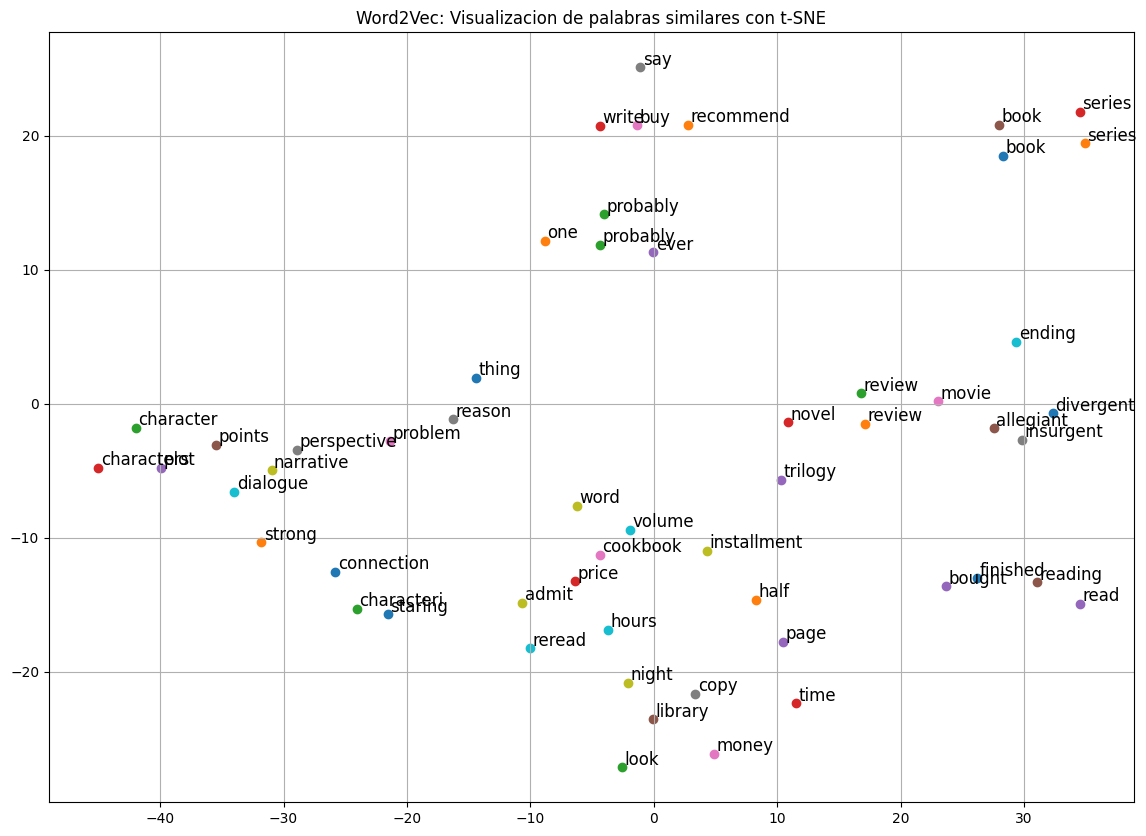

In [28]:
# Visualizamos los word embeddings calculados
plt.figure(figsize=(14, 10))
for i, word in enumerate(words):
    x, y = vectors_2d[i, :]
    plt.scatter(x, y)
    plt.text(x+0.2, y+0.2, word, fontsize=12)

plt.title("Word2Vec: Visualizacion de palabras similares con t-SNE")
plt.grid(True)
plt.show()